In [ ]:
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GroupKFold
from sklearn.metrics import (classification_report, roc_auc_score,
                              mean_squared_error, r2_score)
from sklearn.metrics import precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import os
import shap
from sklearn.metrics import confusion_matrix
import seaborn as sns

from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

import optuna 
from sklearn.model_selection import cross_val_score
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt
import json

import joblib
import os
from sklearn.metrics import mean_squared_error, r2_score

from pathlib import Path
root = Path.cwd()

In [2]:
import sklearn
sklearn.__version__

'1.8.0'

In [ ]:
### instead of optimizing each model's feature set, we select and compare how well each set transfers to new year of data. 
## which type of feature gives most accurate same-year predictions
## which type of feature is most stable across years

## all features
## spectral only
## texture only
## deltas only
## medians only

### Classifier

In [3]:
## read in data
siteyear= 'nyc18'

train_clf_2018 = pd.read_parquet(root / 'data' / siteyear / f'{siteyear}_train_df_clf.parquet')
test_clf_2018 = pd.read_parquet(root / 'data' / siteyear / f'{siteyear}_test_df_clf.parquet')

siteyear= 'nyc21'
train_clf_2021 = pd.read_parquet(root / 'data' / siteyear / f'{siteyear}_train_df_clf.parquet')
test_clf_2021 = pd.read_parquet(root / 'data' / siteyear / f'{siteyear}_test_df_clf.parquet')

In [4]:
def train_clf_models(siteyear, train_df, test_same_year, test_other_year,
                     feature_set, n_seeds=10, shap_n=200):

    band_cols = [c for c in train_df.columns if c.startswith('band')]
    feature_sets = {
        'all_vars':            band_cols,
        'medians_only':        [c for c in band_cols if c.endswith('median')],
        'deltas_only':         [c for c in band_cols if c.endswith('delta')],
        'median_season_only':  [c for c in band_cols if c.endswith('season_median')],
    }
    feature_cols = feature_sets[feature_set]

    X_train = train_df[feature_cols]
    y_train = train_df['canopy_binary']
    X_test_same,  y_test_same  = test_same_year[feature_cols],  test_same_year['canopy_binary']
    X_test_other, y_test_other = test_other_year[feature_cols], test_other_year['canopy_binary']

    # take sample for shap once so it's the same for every iteration
    X_small = X_test_same.sample(min(shap_n, len(X_test_same)), random_state=50)

    same_aucs, other_aucs, shap_cols = [], [], []
    last_clf = None
    for seed in range(n_seeds):
        clf = RandomForestClassifier(n_jobs=-1, random_state=seed)
        clf.fit(X_train, y_train)

        same_aucs.append(roc_auc_score(y_test_same,  clf.predict_proba(X_test_same)[:, 1]))
        other_aucs.append(roc_auc_score(y_test_other, clf.predict_proba(X_test_other)[:, 1]))

        vals = shap.TreeExplainer(clf)(X_small).values[:, :, 1]
        shap_cols.append(np.abs(vals).mean(axis=0))   # (n_features,) per seed
        last_clf = clf

    same_aucs, other_aucs = np.array(same_aucs), np.array(other_aucs)
    shap_mat = np.vstack(shap_cols)                   # (n_seeds, n_features)

    os.makedirs(root / 'models' / siteyear, exist_ok=True)
    joblib.dump({"clf_model": last_clf}, root / 'models' / siteyear / f'{siteyear}_{feature_set}_clf.joblib')

    shap_df = (pd.DataFrame({
        'feature': X_small.columns,
        'mean_abs_shap': shap_mat.mean(axis=0),
        'std_abs_shap':  shap_mat.std(axis=0),
    }).sort_values('mean_abs_shap', ascending=False))
    shap_df.to_csv(root / 'models' / siteyear / f'{siteyear}_clf_shap_{feature_set}_mean.csv', index=False)

    return {
        'train_year':       siteyear,
        'feature_set':      feature_set,
        'n_seeds':          n_seeds,
        'sameyear_auc_mean':  float(same_aucs.mean()),
        'sameyear_auc_std':   float(same_aucs.std()),
        'otheryear_auc_mean': float(other_aucs.mean()),
        'otheryear_auc_std':  float(other_aucs.std()),
    }

In [ ]:
def train_clf_models(siteyear,train_df,test_same_year, test_other_year, feature_set):

    band_cols = [c for c in train_df.columns if c.startswith('band')]

    feature_sets = {'all_vars': band_cols,
    'medians_only' :[c for c in band_cols if c.endswith('median')],
    'deltas_only':[c for c in band_cols if c.endswith('delta')],
    'median_season_only':[c for c in band_cols if c.endswith('season_median')]}

    feature_cols = feature_sets[feature_set]

    X_train = train_df.loc[:,feature_cols]
    y_train = train_df['canopy_binary']

    X_test_sameyear = test_same_year.loc[:,feature_cols]
    y_test_sameyear = test_same_year['canopy_binary']

    X_test_otheryear = test_other_year.loc[:,feature_cols]
    y_test_otheryear = test_other_year['canopy_binary']

    ### iterate over different seeds and save mean/std
    clf = RandomForestClassifier(n_jobs=-1,random_state=42)

    clf.fit(X_train,y_train)

    y_proba_sameyear = clf.predict_proba(X_test_sameyear)[:, 1]
    y_proba_otheryear = clf.predict_proba(X_test_otheryear)[:, 1]
   
    os.makedirs(root / 'models' / siteyear, exist_ok=True)
    joblib.dump({"clf_model":clf}, root / 'models' / siteyear / f'{siteyear}_{feature_set}_clf.joblib')

    sameyear_auc = roc_auc_score(y_test_sameyear, y_proba_sameyear)
    otheryear_auc = roc_auc_score(y_test_otheryear, y_proba_otheryear)
 
    result_dict = {'train_year': siteyear,
                    'feature_set':feature_set,
                   'sameyear_auc': float(sameyear_auc),
                   'otheryear_auc': float(otheryear_auc)}
    
    X_small = X_test_sameyear.sample(100, random_state=50)

    explainer = shap.TreeExplainer(clf)

    shap_values = explainer(X_small)

    vals = shap_values.values[:,:,1]
    mean_abs_shap = np.abs(vals).mean(axis=0)

    shap_df = pd.DataFrame({
        'feature': X_small.columns,
        'mean_abs_shap': mean_abs_shap
    }).sort_values('mean_abs_shap', ascending=False)

    shap_df.to_csv(root / 'models' / siteyear / f'{siteyear}_clf_shap_{feature_set}.csv')

    return result_dict

In [5]:
siteyear = 'nyc21'
all_results = []
for features in ['all_vars','medians_only','deltas_only','median_season_only']:
    results = train_clf_models(siteyear='nyc21',train_df=train_clf_2021,test_same_year=test_clf_2021,test_other_year=test_clf_2018,feature_set=features)
    all_results.append(results)

results_df = pd.DataFrame(all_results)

results_df.to_csv(root / 'models' / siteyear / f'{siteyear}_clf_results_means.csv')

In [ ]:
# save shap plots
siteyear = 'nyc21'

for features in ['all_vars','medians_only','deltas_only','median_season_only']:
    shap_df = pd.read_csv(root / 'models' / siteyear / f'{siteyear}_clf_shap_{features}.csv')

    top30 = shap_df.head(30)
    plt.figure(figsize=(5, 7))
    plt.barh(top30['feature'][::-1], top30['mean_abs_shap'][::-1])
    plt.xlabel('Mean absolute SHAP value')
    plt.title('Feature importance (SHAP) - Classifier')
    plt.tight_layout()

    plt.savefig(root / 'models' / siteyear/ f'{siteyear}_clf_shap_{features}.png')
    

### Regression

In [34]:
siteyear= 'nyc18'

train_rgr_2018 = pd.read_parquet(root / 'data' / siteyear / f'{siteyear}_train_df_rgr.parquet')
test_rgr_2018 = pd.read_parquet(root / 'data' / siteyear / f'{siteyear}_test_df_rgr.parquet')

siteyear= 'nyc21'

train_rgr_2021 = pd.read_parquet(root / 'data' / siteyear / f'{siteyear}_train_df_rgr.parquet')
test_rgr_2021 = pd.read_parquet(root / 'data' / siteyear / f'{siteyear}_test_df_rgr.parquet')

In [43]:

def train_rgr_models(siteyear,train_df,test_same_year, test_other_year, feature_set,shap_n=200,n_seed=10):


    band_cols = [c for c in train_df.columns if c.startswith('band')]
    
    feature_sets = {'all_vars': band_cols,
    'medians_only' :[c for c in band_cols if c.endswith('median')],
    'deltas_only':[c for c in band_cols if c.endswith('delta')],
    'median_season_only':[c for c in band_cols if c.endswith('season_median')]}

    feature_cols = feature_sets[feature_set]

    X_train = train_df.loc[:,feature_cols]
    y_train = train_df['canopy_pct']

    X_test_sameyear = test_same_year.loc[:,feature_cols]
    y_test_sameyear = test_same_year['canopy_pct']

    X_test_otheryear = test_other_year.loc[:,feature_cols]
    y_test_otheryear = test_other_year['canopy_pct']

    X_small = X_test_sameyear.sample(min(shap_n, len(X_test_sameyear)), random_state=50)

    same_r2, same_rmse, other_r2, other_rmse, shap_cols = [], [], [], [], []

    for seed in range(n_seed):
        print(seed)
        rgr = RandomForestRegressor(n_estimators=100,
        min_samples_leaf=5,
        max_depth=20,
        n_jobs=-1,
        random_state=seed)

        rgr.fit(X_train,y_train)

    #joblib.dump({"rgr_model":rgr}, root / 'models' / siteyear / f'{siteyear}_{feature_set}_rgr.joblib')

        y_pred_sameyear = rgr.predict(X_test_sameyear)
        y_pred_otheryear = rgr.predict(X_test_otheryear)
   
        sameyear_rmse = np.sqrt(mean_squared_error(y_test_sameyear, y_pred_sameyear))
        otheryear_rmse = np.sqrt(mean_squared_error(y_test_otheryear, y_pred_otheryear))
        sameyear_r2 = r2_score(y_test_sameyear, y_pred_sameyear)
        otheryear_r2 = r2_score(y_test_otheryear, y_pred_otheryear)

        same_r2.append(sameyear_r2)
        other_r2.append(otheryear_r2)
        same_rmse.append(sameyear_rmse)
        other_rmse.append(otheryear_rmse)

        if seed < 5:
            explainer = shap.TreeExplainer(rgr)
        
            shap_values = explainer(X_small, check_additivity=False)
        
            vals = shap_values.values
            mean_abs_shap = np.abs(vals).mean(axis=0)

            shap_cols.append(mean_abs_shap)
        
         
    same_r2, other_r2 = np.array(same_r2), np.array(other_r2)
    same_rmse, other_rmse = np.array(same_rmse), np.array(other_rmse)
    shap_mat = np.vstack(shap_cols) 

    result_dict = {'train_year': siteyear,
                    'feature_set':feature_set,
                   'sameyear_rmse_mean': float(same_rmse.mean()),
                   'sameyear_rmse_std': float(same_rmse.std()),
                   'otheryear_rmse_mean': float(other_rmse.mean()),
                   'otheryear_rmse_std': float(other_rmse.std()),
                   'sameyear_r2_mean': float(same_r2.mean()),
                   'sameyear_r2_std': float(same_r2.std()),
                   'otheryear_r2_mean': float(other_r2.mean()),
                   'otheryear_r2_std': float(other_r2.std())}
    
    # with open(root /  'models' / siteyear / f'{siteyear}_rgr_{feature_set}_results.json') as f:
    #     json.dump(result_dict,f,indent=2)
    
    shap_df = (pd.DataFrame({
        'feature': X_small.columns,
        'mean_abs_shap': shap_mat.mean(axis=0),
        'std_abs_shap':  shap_mat.std(axis=0),
    }).sort_values('mean_abs_shap', ascending=False))

    shap_df.to_csv(root / 'models' / siteyear / f'{siteyear}_rgr_shap_{feature_set}_mean.csv')
   

    return result_dict

In [ ]:
siteyear = 'nyc18'
all_results = []
for features in ['all_vars', 'deltas_only', 'medians_only','median_season_only']:
    print(features)
    results = train_rgr_models(siteyear=siteyear,train_df=train_rgr_2018,test_same_year=test_rgr_2018,test_other_year=test_rgr_2021,feature_set=features)
    all_results.append(results)

results_df = pd.DataFrame(all_results)

results_df.to_csv(root / 'models' / siteyear / f'{siteyear}_rgr_results_means.csv')

In [ ]:
# save shap plots
siteyear = 'nyc21'
def plot_shap_feature_importance(siteyear):
    os.makedirs(root / 'models' / siteyear / 'shap', exist_ok=True)
    for features in ['all_vars', 'deltas_only', 'medians_only','median_season_only']:
        shap_df = pd.read_csv(root / 'models' / siteyear / f'{siteyear}_rgr_shap_{features}_means.csv')

        top30 = shap_df.head(30)
        plt.figure(figsize=(5, 7))
        plt.barh(top30['feature'][::-1], top30['mean_abs_shap'][::-1])
        plt.xlabel('Mean absolute SHAP value')
        plt.title('Feature importance (SHAP) - Regressor')
        plt.tight_layout()

        plt.savefig(root / 'models' / siteyear/ 'shap' / f'{siteyear}_rgr_shap_{features}.png')

plot_shap_feature_importance(siteyear=siteyear)
    

In [50]:
def plot_shap_feature_importance(output_label):
    os.makedirs(root / 'models' / output_label/ 'shap_plots',exist_ok=True)
    for features in ['all_vars', 'deltas_only', 'medians_only','median_season_only']:
        shap_df_rgr = pd.read_csv(root / 'models' / output_label / f'{output_label}_rgr_shap_{features}_mean.csv')
        shap_df_clf = pd.read_csv(root / 'models'/ output_label / f'{output_label}_clf_shap_{features}_mean.csv')

        top30 = shap_df_rgr.head(30)
        plt.figure(figsize=(5, 7))
        plt.barh(top30['feature'][::-1], top30['mean_abs_shap'][::-1])
        plt.xlabel('Mean absolute SHAP value')
        plt.title('Feature importance (SHAP) - Regressor')
        plt.tight_layout()

        plt.savefig(root / 'models' / output_label/ 'shap_plots' / f'{output_label}_rgr_shap_{features}.png')
        plt.close()

        top30 = shap_df_clf.head(30)
        plt.figure(figsize=(5, 7))
        plt.barh(top30['feature'][::-1], top30['mean_abs_shap'][::-1])
        plt.xlabel('Mean absolute SHAP value')
        plt.title('Feature importance (SHAP) - Classifier')
        plt.tight_layout()
    
        plt.savefig(root / 'models' / output_label/ 'shap_plots' / f'{output_label}_clf_shap_{features}.png')
        plt.close()

In [52]:
plot_shap_feature_importance('nyc18')

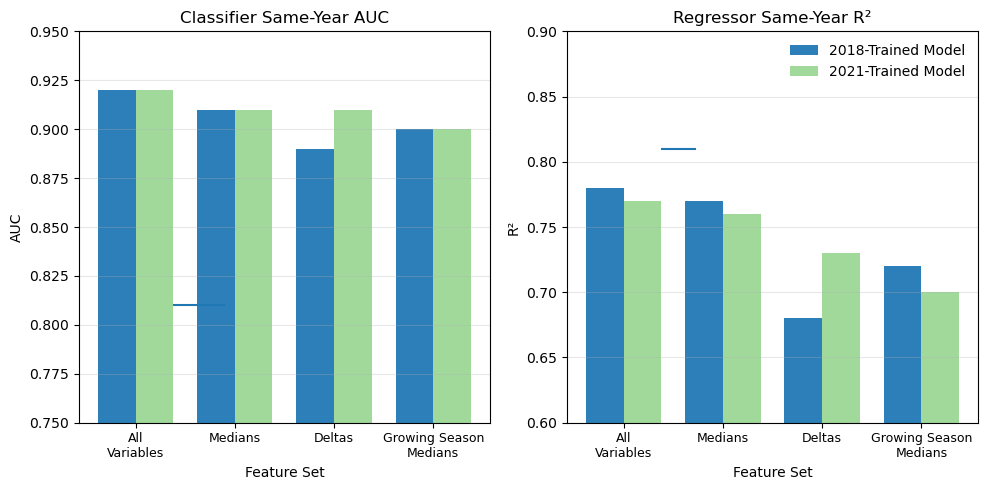

In [2]:
import matplotlib.pyplot as plt
import numpy as np

feature_sets = ['All\nVariables','Medians','Deltas','Growing Season\nMedians']

# (train_year, metric) -> (same_year, cross_year)
clf = {2018: ([0.92,0.91,0.89,0.90], [0.91,0.90,0.89,0.89]),
       2021: ([0.92,0.91,0.91,0.90], [0.89,0.91,0.87,0.89])}
rgr = {2018: ([0.78,0.77,0.68,0.72], [0.70,0.73,0.66,0.68]),
       2021: ([0.77,0.76,0.73,0.70], [0.67,0.75,0.61,0.68])}

fig, axes = plt.subplots(1, 2, figsize=(10,5), sharex=True)
x, w = np.arange(len(feature_sets)), 0.38

for row, (data, label, ylim) in enumerate([(clf, 'Classifier Same-Year AUC', (0.75, 0.95)),
                                           (rgr, 'Regressor Same-Year R²',  (0.60, 0.9))]):
    
    ax = axes[row]
    same18, cross18 = data[2018]
    same21, cross21 = data[2021]
    ax.bar(x - w/2, same18,  w, label='2018-Trained Model',  color='#2c7fb8')
    ax.hlines(x-w/2,cross18,w)
    ax.bar(x + w/2, same21, w, label='2021-Trained Model', color='#a1d99b')
    ax.set_ylim(*ylim)
    ax.set_title(f'{label}')
    ax.set_xlabel('Feature Set')
    
    ax.set_ylabel(label.split(' ')[-1])
    ax.grid(axis='y', alpha=0.3)

axes[0].set_xticks(x)
axes[0].set_xticklabels(feature_sets, fontsize=9, ha='center')
axes[1].set_xticklabels(feature_sets, fontsize=9, ha='center')
axes[1].legend(frameon=False)
plt.tight_layout()

In [ ]:
def read_in_feature_comp_results(output_label):
    c = pd.read_csv(root / 'models' / output_label / f'{output_label}_clf_results_means.csv')
    c = c.rename(columns={'sameyear_auc_mean':'sameyear','otheryear_auc_mean':'otheryear','sameyear_auc_std':'sameyear_std','otheryear_auc_std':'otheryear_std'})
    r = pd.read_csv(root / 'models' / output_label / f'{output_label}_rgr_results_means.csv')
    r = r.rename(columns={'sameyear_r2_mean':'sameyear','otheryear_r2_mean':'otheryear','sameyear_r2_std':'sameyear_std','otheryear_r2_std':'otheryear_std'})
    return c, r

c_18, r_18 = read_in_results('nyc18')
c_21, r_21 = read_in_results('nyc21')


In [32]:
c = pd.read_csv(root / 'models' / 'nyc18' / 'nyc18_clf_results_means.csv')
c

,Unnamed: 0,train_year,feature_set,n_seeds,sameyear_auc_mean,sameyear_auc_std,otheryear_auc_mean,otheryear_auc_std
0,0,nyc18,all_vars,10,0.922128,0.000313,0.912256,0.000265
1,1,nyc18,medians_only,10,0.918097,0.000250,0.910347,0.000379
2,2,nyc18,deltas_only,10,0.905522,0.000290,0.902800,0.000437
3,3,nyc18,median_season_only,10,0.900210,0.000306,0.895544,0.000357


In [20]:
clf = {2018: c_18, 2021: c_21}
rgr = {2018: r_18, 2021: r_21}

colors_18 = ('#007979','#24B1B1')
colors_21 = ('#5FACD3','#97DDE9')

c_label = 'Mean AUC'
r_label = 'Mean R²'

c_ylim = (0.85, 0.93)
r_ylim = (0.60, 0.80)

result_dfs = [(c_18, '2018-trained Classifiers',c_ylim, colors_18,c_label), (c_21, '2021-trained Classifiers',c_ylim,colors_21,c_label),(r_18,'2018-trained Regressors',r_ylim,colors_18,r_label), (r_21, '2021-trained Regressors',r_ylim,colors_21,r_label)]

In [1]:
import sklearn
sklearn.__version__

'1.8.0'

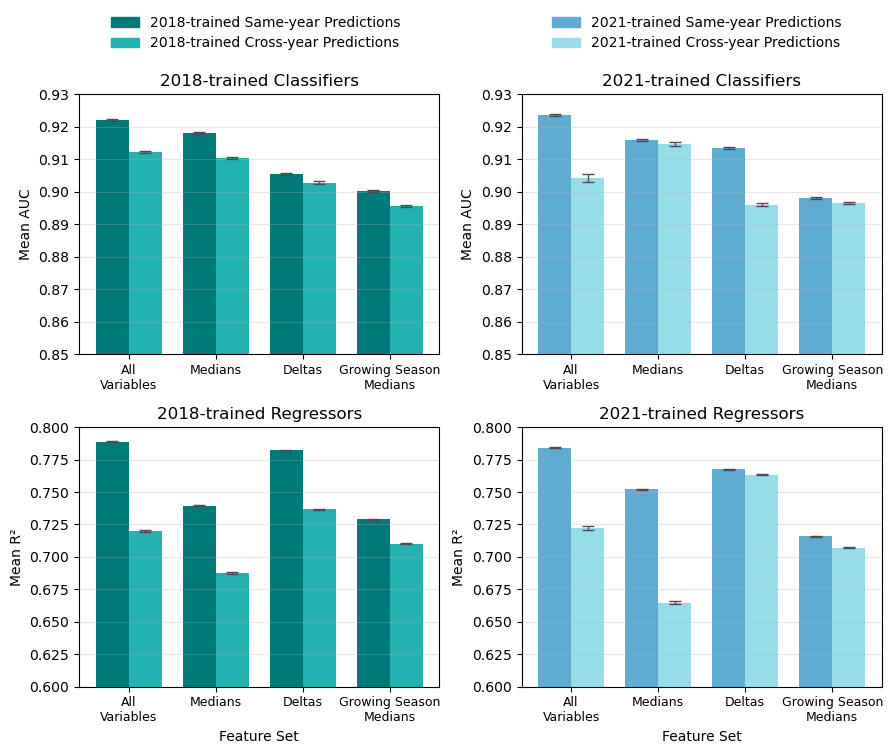

In [ ]:
feature_sets = ['All\nVariables','Medians','Deltas','Growing Season\nMedians']

fig, axes = plt.subplots(2,2,figsize=(9,7))
axes = axes.ravel()

x, w = np.arange(len(feature_sets)), 0.38

for i, (data,title,ylim,colors,label) in enumerate(result_dfs):
    ax = axes[i]
       
    same = data['sameyear']
    same_err = data['sameyear_std']
    cross =data['otheryear']
    cross_err = data['otheryear_std']
    ax.grid(axis='y', alpha=0.3)
    ax.bar(x - w/2, same, w, color=colors[0],label=f'Same-year predictions')
    ax.errorbar(x - w/2, same, yerr=same_err, fmt='none', ecolor='0.3', elinewidth=1,capsize=4,capthick=1)
    ax.bar(x + w/2, cross, w, color=colors[1], label=f'Cross-year predictions')
    ax.errorbar(x + w/2, cross, yerr=cross_err, fmt='none', ecolor='0.3', elinewidth=1,capsize=4,capthick=1)
    ax.set_ylim(*ylim)
    ax.set_title(title)
    if i > 1:
        ax.set_xlabel('Feature Set')
    ax.set_ylabel(label)
    

custom_handles1 = [
Patch(color=colors_18[0], label='2018-trained Same-year Predictions'),
Patch(color=colors_18[1], label='2018-trained Cross-year Predictions')]
labels1 = [h.get_label() for h in custom_handles1]

custom_handles2 = [
Patch(color=colors_21[0], label='2021-trained Same-year Predictions'),
Patch(color=colors_21[1], label='2021-trained Cross-year Predictions')]
labels2 = [h.get_label() for h in custom_handles2]

fig.legend(custom_handles1, labels1, loc='upper center', ncol=1, frameon=False, bbox_to_anchor=(0.28, 1.08))
fig.legend(custom_handles2, labels2, loc='upper center', ncol=1, frameon=False, bbox_to_anchor=(0.77, 1.08))
for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(feature_sets, fontsize=9, ha='center')
plt.tight_layout()


### very small standard devations show that the differences between feature sets is real and not algorithm noise

## all classifiers perform well. between 0.89 and 0.92. 

### regressors: deltas show best transferability both years. possibly because deltas capture relative change. medians may vary due to cooler or warmer temperatures, or more or less precipitation, but the relative difference between seasons may stay more consistent. therefore, deltas are robust to uniform climate shifts while medians are not.
## could it also mitigate inconsistency in number/timing of data acquisition?
# would need a third year of reference data to fully test this.
# also visualization of the stability of deltas v medians year to year would be useful.

## feature importance shows that spring delta tdvi is most important in all_vars and deltas for both years

## most robust version of the pipeline would composite based on growing degree days, not calendar windows, to ensure the same phenological stage is captured each year. 


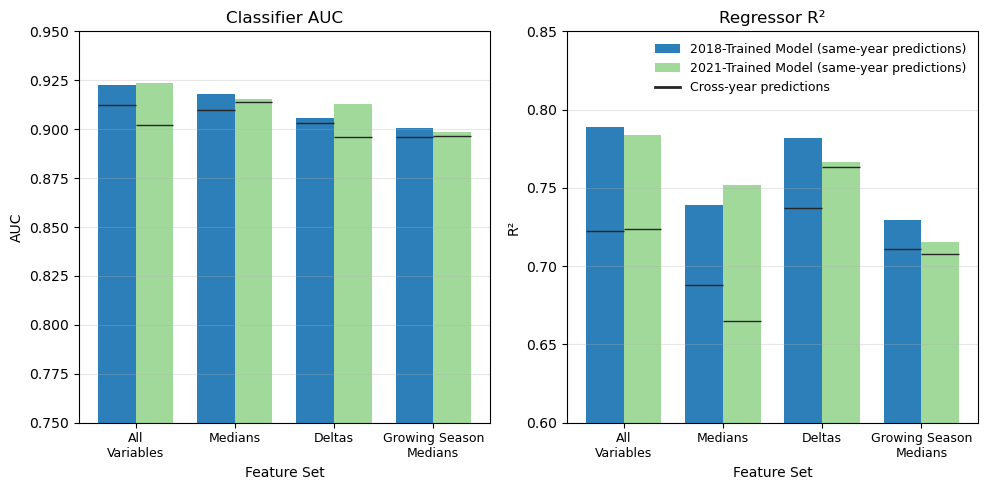

In [ ]:


# (train_year, metric) -> (same_year, cross_year)
# clf = {2018: ([0.92,0.91,0.89,0.90], [0.91,0.90,0.89,0.89]),
#        2021: ([0.92,0.91,0.91,0.90], [0.89,0.91,0.87,0.89])}
# rgr = {2018: ([0.78,0.77,0.68,0.72], [0.70,0.73,0.66,0.68]),
#        2021: ([0.77,0.76,0.73,0.70], [0.67,0.75,0.61,0.68])}


fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True)
x, w = np.arange(len(feature_sets)), 0.38

for row, (data, label, ylim) in enumerate([(clf, 'Classifier AUC', (0.75, 0.95)),
                                            (rgr, 'Regressor R²',  (0.60, 0.85))]):
    ax = axes[row]
    for off, year, color in [(-w/2, 2018, '#2c7fb8'), (w/2, 2021, '#a1d99b')]:
        #same, cross = data[year]
        same = data[year]['sameyear']
        cross =data[year]['otheryear']
        ax.bar(x + off, same, w, color=color, label=f'{year}-Trained Model (same-year predictions)')
        ax.hlines(cross, (x + off) - w/2, (x + off) + w/2,
                  color='0.15', lw=1, zorder=3)

    ax.set_ylim(*ylim)
    ax.set_title(label)
    ax.set_xlabel('Feature Set')
    ax.set_ylabel(label.split(' ')[-1])
    ax.grid(axis='y', alpha=0.3)

# one proxy handle so the tick appears in the legend
from matplotlib.lines import Line2D
handles, lbls = axes[1].get_legend_handles_labels()
handles.append(Line2D([0], [0], color='0.15', lw=2))
lbls.append('Cross-year predictions')
axes[1].legend(handles, lbls, frameon=False, fontsize=9)

axes[0].set_xticks(x)
for ax in axes:
    ax.set_xticklabels(feature_sets, fontsize=9, ha='center')
plt.tight_layout()

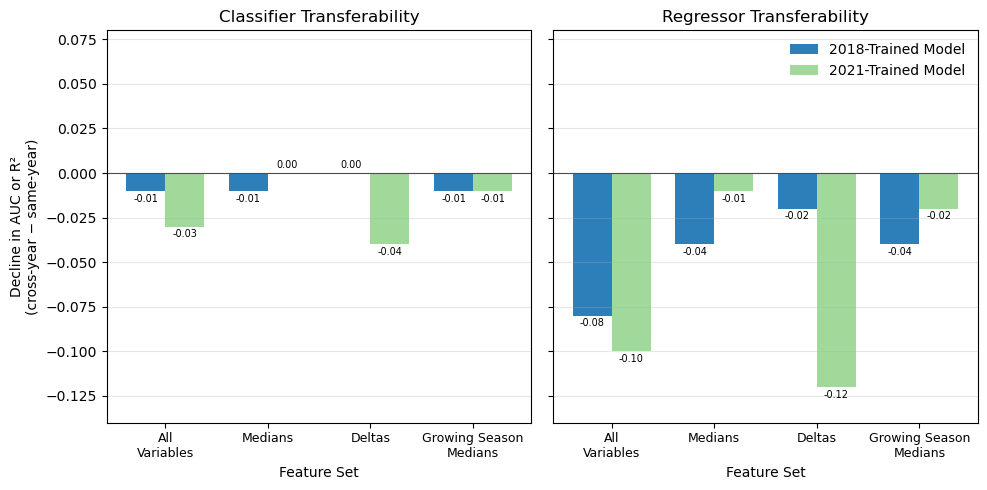

In [ ]:
### separate plots version

feature_sets = ['All\nVariables','Medians','Deltas','Growing Season\nMedians']

# same-year and cross-year, per train year
clf = {2018: ([0.92,0.91,0.89,0.90], [0.91,0.90,0.89,0.89]),
       2021: ([0.92,0.91,0.91,0.90], [0.89,0.91,0.87,0.89])}
rgr = {2018: ([0.78,0.77,0.68,0.72], [0.70,0.73,0.66,0.68]),
       2021: ([0.77,0.76,0.73,0.70], [0.67,0.75,0.61,0.68])}

def drops(d, year):
    same, cross = d[year]
    return np.array(cross) - np.array(same)

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
x, w = np.arange(len(feature_sets)), 0.38

for ax, (data, title) in zip(axes, [(clf, 'Classifier Transferability'), (rgr, 'Regressor Transferability')]):
    d18, d21 = drops(data, 2018), drops(data, 2021)
    b1 = ax.bar(x - w/2, d18, w, label='2018-Trained Model', color='#2c7fb8')
    b2 = ax.bar(x + w/2, d21, w, label='2021-Trained Model', color='#a1d99b')
    ax.axhline(0, color='0.3', lw=0.8)
    ax.set_ylim(-0.14,0.08)
    ax.set_title(title)
    ax.set_xlabel('Feature Set')
    ax.set_xticks(x)
    ax.set_xticklabels(feature_sets, rotation=0, fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    for b in (b1, b2):
        ax.bar_label(b, fmt='%.2f', padding=2, fontsize=7)

axes[0].set_ylabel(f'Decline in AUC or R²\n(cross-year − same-year)')
# axes[0].annotate('lower = transfers better', xy=(0.02, 0.95), xycoords='axes fraction',
#                  fontsize=8, style='italic', va='top')
axes[1].legend(frameon=False, loc='upper right')
plt.tight_layout()

#### Pipeline Distribution Plot

In [35]:
## read in data
siteyear= 'nyc18'
test_clf_2018 = pd.read_parquet(root / 'data' / siteyear / f'{siteyear}_test_df_clf_nonstratified.parquet')
test_rgr_2018 = pd.read_parquet(root / 'data' / siteyear / f'{siteyear}_test_df_rgr_nonstratified.parquet')

siteyear= 'nyc21'
test_clf_2021 = pd.read_parquet(root / 'data' / siteyear / f'{siteyear}_test_df_clf_nonstratified.parquet')
test_rgr_2018 = pd.read_parquet(root / 'data' / siteyear / f'{siteyear}_test_df_rgr_nonstratified.parquet')

## read in model
siteyear = 'nyc21'
clf = joblib.load(root / 'models' / siteyear / f'{siteyear}_medians_only_clf.joblib')['clf_model']
rgr = joblib.load(root / 'models' / siteyear / f'{siteyear}_medians_only_rgr.joblib')['rgr_model']

band_cols = [c for c in test_rgr_2018.columns if c.startswith('band')]
texture_names = ['contrast', 'dissimilarity', 'homogeneity','ASM', 'variance','entropy']
spectral_only = [c for c in band_cols if not any(t in str(c) for t in texture_names)]

feature_sets = {'all_vars': band_cols,
    'spectral_only' :spectral_only,
    'medians_only' :[c for c in spectral_only if not any(t in str(c) for t in ['delta','iqr'])],
    'deltas_only':[c for c in spectral_only if not any(t in str(c) for t in ['median','iqr'])],
    'median_season_only':[c for c in spectral_only if c.endswith('season_median')]}

In [ ]:
X_test = test_clf_2018[feature_sets['medians_only']]
y_test = test_clf_2018['canopy_pct']

clf_preds = clf.predict(X_test)

tc_percent = np.full(len(y_test),0)
canopy_mask = clf_preds == 1

tc_percent[canopy_mask] = rgr.predict(X_test[canopy_mask])

rgr_only_preds = rgr.predict(X_test)


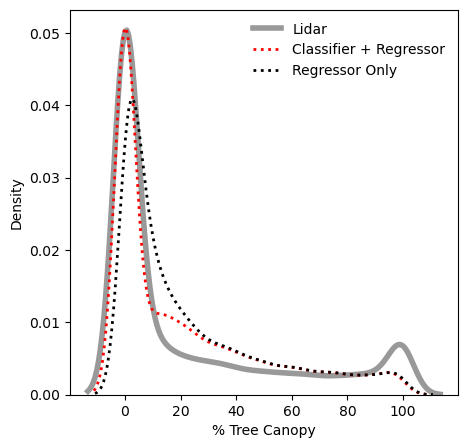

In [68]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(5,5))
sns.kdeplot(y_test,ax=ax,color='black',alpha=0.4,lw=4,label='Lidar')
sns.kdeplot(tc_percent,ax=ax,color='red',lw=2,linestyle='dotted',label='Classifier + Regressor')
sns.kdeplot(rgr_only_preds,ax=ax,color='black',lw=2,linestyle='dotted',label='Regressor Only')

ax.set_xlabel('% Tree Canopy')
plt.legend(frameon=False)
plt.show()

### Train Final Models

In [36]:
### for deployment, use train and test datasets to train
## suitable to evaluate cross-year only
siteyear= 'nyc21'
feature_set = 'medians_only'

train_clf = pd.read_parquet(root / 'data' / siteyear / f'{siteyear}_train_df_clf_nonstratified.parquet')
test_clf = pd.read_parquet(root / 'data' / siteyear / f'{siteyear}_test_df_clf_nonstratified.parquet')
train_rgr = pd.read_parquet(root / 'data' / siteyear / f'{siteyear}_train_df_rgr_nonstratified.parquet')
test_rgr = pd.read_parquet(root / 'data' / siteyear / f'{siteyear}_test_df_rgr_nonstratified.parquet')

all_training_data = pd.concat([train_clf,test_clf,train_rgr,test_rgr])

band_cols = [c for c in train_clf.columns if c.startswith('band')]
texture_names = ['contrast', 'dissimilarity', 'homogeneity','ASM', 'variance','entropy']
spectral_only = [c for c in band_cols if not any(t in str(c) for t in texture_names)]
medians_only = [c for c in spectral_only if not any(t in str(c) for t in ['delta','iqr'])]

X = all_training_data[medians_only]
y_binary = all_training_data['canopy_binary']
y_pct = all_training_data['canopy_pct']




In [97]:
train_data = pd.concat([train_clf,train_rgr])
test_data = pd.concat([test_clf,test_rgr])

X_train = train_data[medians_only]
y_train_binary = train_data['canopy_binary']
y_train_pct = train_data['canopy_pct']

In [ ]:
#filename = 'fulldata'
filename = 'traindata'

def train_clf_rgr_models(all_training_data,feature_sets,feature_set_name):

    X = all_training_data[feature_sets[feature_set_name]]
    y_binary = all_training_data['canopy_binary']
    y_pct = all_training_data['canopy_pct']

    print('Training classifier')
    clf = RandomForestClassifier(n_jobs=-1,random_state=42)

    clf.fit(X,y_binary)

    print('Training regressor')
    rgr = RandomForestRegressor( n_estimators=100,
        min_samples_leaf=5,
        max_depth=20,
        n_jobs=-1,
        random_state=42)

    rgr.fit(X,y_pct)

    joblib.dump({"clf_model":clf,"rgr_model":rgr}, config.MODELS / output_label / f'{output_label}_{feature_set_name}_models.joblib')
    print(f'Done. Trained models saved to : {config.MODELS} / output_label / {output_label}_{feature_set_name}_models.joblib')

['c:\\Users\\roseh\\Documents\\utc_paper\\models\\nyc21\\nyc21_medians_only_traindata_rgr.joblib']

In [35]:
## OOF predictions for 2021
## allows us to validate whole map not just test blocks, which is better for later aggregation and change analysis

from sklearn.base import clone



def train_oof_models(train_df, feature_cols, block_col='block_id', k=5, seed=42):
    # add block id col to train df
    train_df['block_id'] = train_df['block_row'].astype(str) + '_' + train_df['block_col'].astype(str)
    # assign each spatial block to a fold 
    blocks = train_df[block_col].unique()
    rng = np.random.default_rng(seed)
    fold_of_block = {b: i % k for i, b in enumerate(rng.permutation(blocks))}
    train_df = train_df.assign(fold=train_df[block_col].map(fold_of_block))

    # make fold array: assign pixels to folds based on fold_of_block dictionary
    # read in existing block map for size refernce
    block_map = np.load(root / 'data' / 'nyc21' / 'train_test_blocks.npz')
    block_map = block_map['arr_0']

    block_size = 100
    ny, nx = block_map.shape
    n_blocks_y = ny // block_size   # drop partial edge tiles
    n_blocks_x = nx // block_size

    fold_array = np.full((ny, nx), 7, dtype=np.uint16)
    for by in range(n_blocks_y):
        for bx in range(n_blocks_x):
            f = fold_of_block.get(f'{by}_{bx}')
            if f is None:
                continue
            y0, y1 = by * block_size, (by + 1) * block_size
            x0, x1 = bx * block_size, (bx + 1) * block_size
            fold_array[y0:y1, x0:x1] = f

    base_clf = RandomForestClassifier(n_jobs=-1,random_state=42)
    base_rgr = RandomForestRegressor( n_estimators=100,   
                                            min_samples_leaf=5,
                                            max_depth=20,
                                            n_jobs=-1,
                                            random_state=42)

    models = {}
    for f in range(k):
        print(f)
        tr = train_df[train_df.fold != f]  # leave current fold out of training
        clf = clone(base_clf).fit(tr[feature_cols], tr['canopy_binary'])
     
        rgr = clone(base_rgr).fit(tr[feature_cols], tr['canopy_pct'])
        models[f] = (clf, rgr)
    return models, fold_of_block, fold_array

In [ ]:
mods, fob, fold_array = train_oof_models(train_df=all_training_data,feature_cols=medians_only)

0
1
2
3
4


In [39]:
joblib.dump({'models':mods,'fold':fob,'fold_array':fold_array},root / 'models' / 'nyc21' / 'nyc21_medians_only_OOF_models.joblib' )

['c:\\Users\\roseh\\Documents\\utc_paper\\models\\nyc21\\nyc21_medians_only_OOF_models.joblib']

### Plot Feature Ranks Comparison

In [70]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

all_dfs = []
for f in list((root/ 'models' / 'nyc21').glob(f'*_shap_*.csv')) + list((root/ 'models' / 'nyc18').glob(f'*_shap_*.csv')):
    name = f.name.split('.')[0]
    df = pd.read_csv(f,index_col=0)
    df['name'] = name
    df['num'] = range(1,len(df)+1)
    all_dfs.append(df)

out = pd.concat(all_dfs, axis=0)

In [71]:
out_top = out.loc[out['num']<=30].copy()
keep = [n for n in out_top['name'].unique() if 'medians_only' in n] ## just one feature set
med_only = out_top.loc[out_top['name'].isin(keep)].copy()
pivot = med_only.pivot_table(index='feature',columns='name',values='num',aggfunc='min')

In [72]:
counts = pivot.notna().sum(axis=1)
mean_rank = pivot.mean(axis=1)

order = (pd.DataFrame({'n':counts,'mr':mean_rank}).sort_values(['n','mr'],ascending=[False,True]).index)

pivot = pivot.loc[order]
counts = counts.loc[order]

n_feat, n_mod = pivot.shape

In [73]:
## clean up labels when index is in correct order

replacements = {'band_':'','_':' ','tdv':'TDVI','ndr':'NDRE','bsi':'BSI','ndm':'NDMI','psr':'PSRI','nbr':'NBR','grv':'GRVI',
                's2w':'S2WI','summer':'Summer','fall':'Fall','spring':'Spring','median':'Median','season':'Season'}
labels = []
for t in list(pivot.index):
    for old,new in replacements.items():
        t = t.replace(old,new)
    labels.append(t)


In [ ]:
fig, ax = plt.subplots(figsize=(4, 12))

vals = np.ma.masked_invalid(pivot.values)
cmap = plt.get_cmap("viridis").copy()
cmap.set_bad("#f2f2f2")                     # absent = light grey
norm = Normalize(vmin=1, vmax=30)
im = ax.imshow(vals, cmap=cmap, norm=norm, aspect="auto")

for i, feat in enumerate(pivot.index):
    for j, model in enumerate(pivot.columns):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, int(v), ha="center", va="center", fontsize=7,
                    color="white" if v <= 30 / 2 else "black")
            
ax.set_xticks(range(n_mod))
ax.set_xticklabels(['2018\nClf.','2018\nRgr.','2021\nClf.','2021\nRgr.'],ha="center", fontsize=10)
ax.xaxis.set_ticks_position("top")
ax.set_yticks(range(n_feat))
ax.set_yticklabels(labels=labels, fontsize=10)
ax.tick_params(length=0)

plt.tight_layout()
plt.show()

##### Cluster correlated variables

In [7]:
## cluster correlated variables
# reduce correlated groups down to a single 'representative' variable
t = 0.15
corr = pd.DataFrame(X_sample).corr().abs()
distance = 1 - corr
linkage = hierarchy.ward(squareform(distance))
labels = hierarchy.fcluster(linkage, t=t, criterion='distance')

# for each cluster, keep the one variable with highest shap value
selected = []
for cluster_id in np.unique(labels):
    members = X_sample.columns[labels == cluster_id]
    # Pick member with highest mean absolute SHAP
    best = shap_df[shap_df['feature'].isin(members)].iloc[0]['feature']
    selected.append(best)

print(f'number of clusters: {len(selected)}')
#402

number of clusters: 371


##### Test models with increasing number of variables

In [8]:
#### plot baseline scores with increasing number of features


def test_features_clf(features,X_train,X_test,y_train,y_test):
    auc_scores = []
    num_features = []

     # Step through feature counts rather than every single one
    steps = list(range(1, 20)) + list(range(20, 100, 5)) + list(range(100, len(features)+1, 20))
    steps = [s for s in steps if s <= len(features)]

    for i in steps:
        feature_set = features[0:i+1]
        X_train_reduced = X_train[feature_set]
        X_test_reduced = X_test[feature_set]
        
        # fit model 
        rf_explore = RandomForestClassifier(
            n_estimators=100,
            max_features="sqrt",
            n_jobs=-1,
            random_state=42,
        )
        rf_explore.fit(X_train_reduced, y_train)

        baseline_auc = roc_auc_score(y_test, rf_explore.predict_proba(X_test_reduced)[:, 1])
        auc_scores.append(baseline_auc)
        num_features.append(X_train_reduced.shape[1])

    out_df = pd.DataFrame({'num_features':num_features,'auc_scores':auc_scores})

    return out_df




In [9]:
# Reorder features by SHAP importance before passing to the function
features_ordered = shap_df[shap_df['feature'].isin(selected)]['feature'].tolist()
results = test_features_clf(features_ordered,X_train=X_train,X_test=X_test,y_train=y_train,y_test=y_test)

In [10]:
results.loc[results['auc_scores']==results['auc_scores'].max()]

,num_features,auc_scores
34,96,0.914354


In [11]:
results.loc[(results['num_features']>40)&(results['num_features']<=95)]

,num_features,auc_scores
23,41,0.911841
24,46,0.912092
25,51,0.911587
26,56,0.912049
27,61,0.912828
28,66,0.912883
29,71,0.913331
30,76,0.913452
31,81,0.913333
32,86,0.913658


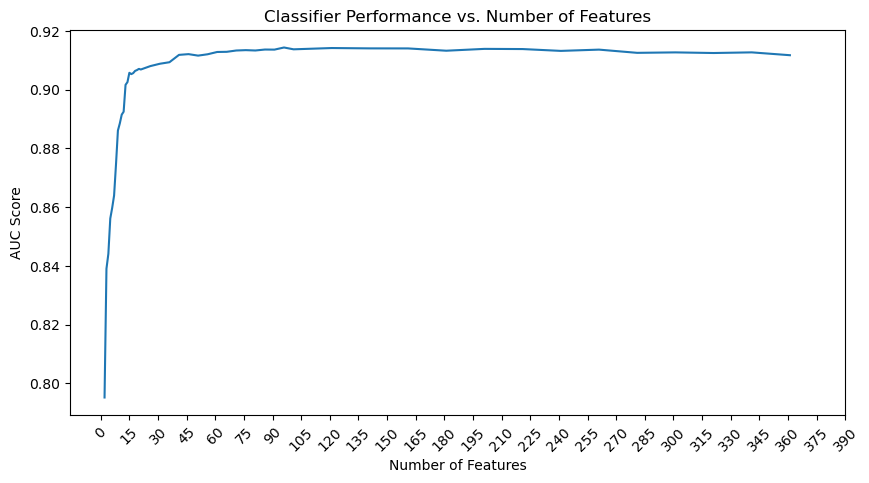

In [12]:
fig,ax = plt.subplots(figsize=(10,5))
results.plot(x='num_features',y='auc_scores',ax=ax,legend=False)
ax.set_xticks(np.arange(0,400,15))
ax.set_xticklabels(labels=ax.get_xticks(),rotation=45)
ax.set_ylabel('AUC Score')
ax.set_xlabel('Number of Features')
ax.set_title('Classifier Performance vs. Number of Features')

plt.show()

In [13]:
# keep top 50 and write to file
keep_features = features_ordered[:51]

fp = root / 'data' / siteyear / 'clf_features.json'

with open(fp,'w') as f:
    json.dump(keep_features,f)

### Tune clf using selected features only

In [14]:
## read in data
train_df = pd.read_parquet(root / 'data' / siteyear / 'train_df_clf_nonstratified.parquet')
test_df = pd.read_parquet(root / 'data' / siteyear / 'test_df_clf_nonstratified.parquet')

# read in feature names to use for training
fp = root / 'data' / siteyear / 'clf_features.json'
with open(fp,'r') as f:
    feature_cols = json.load(f)

X_train = train_df[feature_cols]
y_train = train_df['canopy_binary']
X_test = test_df[feature_cols]
y_test = test_df['canopy_binary']

## groups to make sure train/test pixels are sampled from different blocks
block_ids_tr = (train_df["block_row"].astype(str) + "_"
                + train_df["block_col"].astype(str))
group_encoder = {g: i for i, g in enumerate(block_ids_tr.unique())}
groups_tr = block_ids_tr.map(group_encoder).values

n_cv_folds = min(5, len(np.unique(groups_tr)))
cv_spatial = GroupKFold(n_splits=n_cv_folds)


In [15]:
def objective(trial):

    params= {
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf" : trial.suggest_int("min_samples_leaf", 1, 10),
        "max_samples"      : trial.suggest_float("max_samples", 0.6, 1.0)}
    
    clf = RandomForestClassifier(**params,n_estimators=200,max_features='sqrt',n_jobs=1,random_state=42)

    scores = cross_val_score(clf,X_train,y_train,cv=cv_spatial,groups=groups_tr,scoring='roc_auc',n_jobs=-1)

    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective,n_trials=10,show_progress_bar=True)

[I 2026-05-07 18:02:28,210] A new study created in memory with name: no-name-30c369cd-2ee7-4dfd-89a5-6552b17ad6e6


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-05-07 18:03:48,882] Trial 0 finished with value: 0.9148721162072114 and parameters: {'min_samples_split': 5, 'min_samples_leaf': 4, 'max_samples': 0.9955466592525035}. Best is trial 0 with value: 0.9148721162072114.
[I 2026-05-07 18:04:53,603] Trial 1 finished with value: 0.9140426576577638 and parameters: {'min_samples_split': 9, 'min_samples_leaf': 8, 'max_samples': 0.648002580195774}. Best is trial 0 with value: 0.9148721162072114.
[I 2026-05-07 18:05:56,912] Trial 2 finished with value: 0.9143880832181288 and parameters: {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_samples': 0.6070989127784896}. Best is trial 0 with value: 0.9148721162072114.
[I 2026-05-07 18:07:11,109] Trial 3 finished with value: 0.9139868928528359 and parameters: {'min_samples_split': 10, 'min_samples_leaf': 1, 'max_samples': 0.6975726086269565}. Best is trial 0 with value: 0.9148721162072114.
[I 2026-05-07 18:08:34,665] Trial 4 finished with value: 0.9150460439513417 and parameters: {'min_sample

In [16]:
best_params = study.best_params
# best_params = {'min_samples_split': 7,
#  'min_samples_leaf': 4,
#  'max_samples': 0.8592247437133163}
best_params

{'min_samples_split': 5,
 'min_samples_leaf': 3,
 'max_samples': 0.9530885060659483}

In [17]:


best_clf = RandomForestClassifier(
    **best_params, n_estimators=200,max_features='sqrt',class_weight='balanced',n_jobs=-1,random_state=42
)
best_clf.fit(X_train, y_train) ## fit on all training data

y_pred  = best_clf.predict(X_test)
y_proba = best_clf.predict_proba(X_test)[:, 1]
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["No canopy", "Canopy"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

# stratified training data
# Classification report:
#               precision    recall  f1-score   support

#    No canopy       0.86      0.65      0.74      9957
#       Canopy       0.77      0.92      0.84     12799   ### favored recall over precision

#     accuracy                           0.80     22756
#    macro avg       0.81      0.78      0.79     22756
# weighted avg       0.81      0.80      0.79     22756

# ROC-AUC: 0.9045


### non stratified training data
# Classification report:
#               precision    recall  f1-score   support

#    No canopy       0.80      0.83      0.81      9800   ### big improvement of no canopy recall (.65 to .83)
#       Canopy       0.87      0.84      0.85     12999

#     accuracy                           0.83     22799
#    macro avg       0.83      0.83      0.83     22799
# weighted avg       0.83      0.83      0.83     22799

# ROC-AUC: 0.9143

#### resampled training data
# Classification report:
#               precision    recall  f1-score   support

#    No canopy       0.80      0.82      0.81      9802
#       Canopy       0.86      0.84      0.85     13002

#     accuracy                           0.83     22804
#    macro avg       0.83      0.83      0.83     22804
# weighted avg       0.84      0.83      0.83     22804

# ROC-AUC: 0.9150

### season only
# Classification report:
#               precision    recall  f1-score   support

#    No canopy       0.77      0.79      0.78      9800
#       Canopy       0.84      0.83      0.83     12999

#     accuracy                           0.81     22799
#    macro avg       0.81      0.81      0.81     22799
# weighted avg       0.81      0.81      0.81     22799

# ROC-AUC: 0.8967

#### 2017 resampled ####
# Classification report:
#               precision    recall  f1-score   support

#    No canopy       0.78      0.83      0.80      8949
#       Canopy       0.86      0.82      0.84     11625

#     accuracy                           0.82     20574
#    macro avg       0.82      0.83      0.82     20574
# weighted avg       0.83      0.82      0.83     20574

# ROC-AUC: 0.9065


Classification report:
              precision    recall  f1-score   support

   No canopy       0.80      0.84      0.82     10514
      Canopy       0.86      0.82      0.84     12600

    accuracy                           0.83     23114
   macro avg       0.83      0.83      0.83     23114
weighted avg       0.83      0.83      0.83     23114

ROC-AUC: 0.9135


In [ ]:
## adjust decision threshold
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test,y_proba)

target_recall = 0.93
idx = np.where(recalls >= target_recall)[0][-1]
best_thresh = thresholds[idx]

print(f"Threshold {best_thresh:.3f} → "
      f"recall={recalls[idx]:.3f}, precision={precisions[idx]:.3f}")

#Threshold 0.360 → recall=0.900, precision=0.770 ## old feature selection method

#Threshold 0.344 → recall=0.950, precision=0.967 ## train/test dataset mix up; trained on nonstratified test dataset

# Threshold 0.452 → recall=0.950, precision=0.718 ## old features selected on 20k dataset

#Threshold 0.373 → recall=0.950, precision=0.721  ## new features selected on 60k stratified dataset

### 2017 resampled
#Threshold 0.295 → recall=0.930, precision=0.753

## 2018
#Threshold 0.294 → recall=0.930, precision=0.751

Threshold 0.294 → recall=0.930, precision=0.751


In [19]:

### confirm threshold optimal based on number of zero canopy pixels retained
for thresh in [0.25,0.29,0.3, 0.35,0.38,0.40, 0.50, 0.60]:
    preds = (y_proba >= thresh).astype(int)
    recall = recall_score(y_test, preds,pos_label=1)
    precision = precision_score(y_test, preds,pos_label=1)
    n_zeros_passing = ((preds == 1) & (y_test == 0)).sum() # num actual zero pixels
    print(f"thresh={thresh:.2f}  recall={recall:.3f}  "
          f"precision={precision:.3f}  zeros_passing={n_zeros_passing:,}")
    
# ambiguous pixels (zeros passing) will be handled by the regressor and likely assigned very low canopy percentages.
# possibly these are wetland/shrub ecosystems.

## between 0.2 and 0.3, recall of actual canopy drops.
# we want to minimize # of zeros passing but still have good recall of actual canopy

### stratified training data
# thresh=0.20  recall=0.980  precision=0.650  zeros_passing=6,758
# thresh=0.35  recall=0.955  precision=0.712  zeros_passing=4,951
# thresh=0.40  recall=0.944  precision=0.732  zeros_passing=4,422
# thresh=0.42  recall=0.938  precision=0.739  zeros_passing=4,231
# thresh=0.46  recall=0.929  precision=0.754  zeros_passing=3,881
# thresh=0.50  recall=0.917  precision=0.769  zeros_passing=3,528

# non stratified training data
# thresh=0.20  recall=0.968  precision=0.705  zeros_passing=5,276
# thresh=0.25  recall=0.953  precision=0.736  zeros_passing=4,433
# thresh=0.30  recall=0.937  precision=0.767  zeros_passing=3,708
# thresh=0.35  recall=0.915  precision=0.791  zeros_passing=3,134
# thresh=0.38  recall=0.902  precision=0.806  zeros_passing=2,815
# thresh=0.40  recall=0.891  precision=0.815  zeros_passing=2,623
# thresh=0.50  recall=0.840  precision=0.865  zeros_passing=1,703
# thresh=0.60  recall=0.775  precision=0.906  zeros_passing=1,046

thresh=0.25  recall=0.946  precision=0.723  zeros_passing=4,563
thresh=0.29  recall=0.932  precision=0.749  zeros_passing=3,941
thresh=0.30  recall=0.927  precision=0.754  zeros_passing=3,819
thresh=0.35  recall=0.905  precision=0.782  zeros_passing=3,173
thresh=0.38  recall=0.890  precision=0.801  zeros_passing=2,783
thresh=0.40  recall=0.880  precision=0.813  zeros_passing=2,548
thresh=0.50  recall=0.822  precision=0.864  zeros_passing=1,634
thresh=0.60  recall=0.756  precision=0.906  zeros_passing=990


In [16]:
best_thresh

np.float64(0.31638003697804923)

In [20]:
#save best_estimator and features

### model trained with unbuffered texture metrics 
import joblib
import os

out_path = root / 'models' / siteyear
os.makedirs(out_path,exist_ok=True)

joblib.dump({"clf_model":best_clf,
         "features":feature_cols,
         'threshold':best_thresh,
         "params": best_params}, out_path / f'{siteyear}_clf.joblib')

['c:\\Users\\roseh\\Documents\\utc_paper\\models\\nyc18\\nyc18_clf.joblib']

### Filter Regression Dataset using classifer

In [29]:

train_df = pd.read_parquet(root / 'data' / siteyear / 'train_df_rgr_nonstratified_resampled.parquet')
test_df = pd.read_parquet(root / 'data' / siteyear / 'test_df_rgr_nonstratified_resampled.parquet')

feature_cols = [c for c in train_df.columns if c.startswith('band')]

# only season vars
#feature_cols = [c for c in feature_cols if 'season' in c]

In [30]:
## read in clf model

clf_bundle = joblib.load(root / 'models' / siteyear / f'{siteyear}_clf.joblib')
clf = clf_bundle["clf_model"]
features = clf_bundle["features"]
threshold = clf_bundle["threshold"]
params = clf_bundle['params']

clf_feat_idx = [feature_cols.index(f) for f in features]

In [20]:
######### use clf model to filter out (most) zero canopy pixels
RANDOM_STATE=42
# return indexes of predicted canopy pixels
def filter_canopy(df,clf,clf_feat_idx,threshold):
    df_feats = df.iloc[:,clf_feat_idx]
    preds = clf.predict_proba(df_feats)[:,1]
    return df[preds >= threshold].copy()

## use oob preds to filter training data because it's the same data that was used to train classifier
def filter_canopy_unbiased(df,params,clf_feat_idx,threshold):

    x_df = df.iloc[:,clf_feat_idx]
    y = df['canopy_binary']

    clf_oob = RandomForestClassifier(
        oob_score=True,
        **params,
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
    clf_oob.fit(x_df, y)

    # OOB predicted probabilities for the training set
    oob_proba = clf_oob.oob_decision_function_[:, 1]  # positive class
    canopy_mask_oob = oob_proba >= threshold
    # Use this mask to filter training data for the regressor
    return df[canopy_mask_oob].copy()


train_filtered = filter_canopy(train_df,clf,clf_feat_idx,threshold=threshold)
test_filtered = filter_canopy(test_df,clf,clf_feat_idx,threshold=threshold)

X_train = train_filtered.loc[:,feature_cols]
y_train = train_filtered['canopy_pct']

X_test = test_filtered.loc[:,feature_cols]
y_test = test_filtered['canopy_pct']

count    62478.000000
mean        45.743237
std         31.518415
min          0.000000
25%         17.689153
50%         45.101322
75%         72.597666
max        100.000000
Name: canopy_pct, dtype: float64
% pixels below 10% canopy: 17.7%


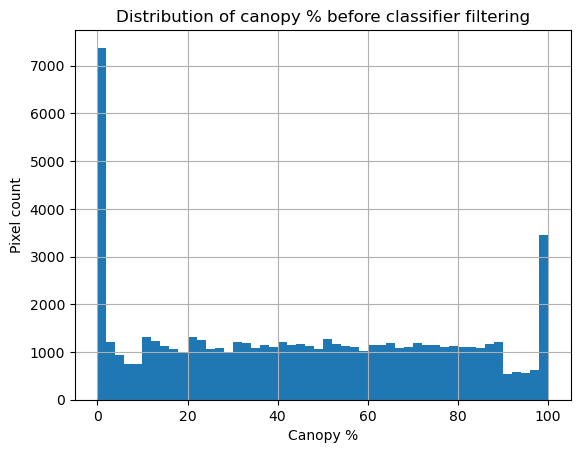

In [21]:
train_df['canopy_pct'].hist(bins=50)
plt.xlabel("Canopy %")
plt.ylabel("Pixel count")
plt.title("Distribution of canopy % before classifier filtering")
plt.savefig("y_train_dist_stratified_sampling.png")

print(train_df['canopy_pct'].describe())
print(f"% pixels below 10% canopy: {100*(train_df['canopy_pct'] < 10).mean():.1f}%")

count    56939.000000
mean        49.600327
std         30.093908
min          0.000000
25%         23.911019
50%         49.819981
75%         74.930717
max        100.000000
Name: canopy_pct, dtype: float64
% pixels below 10% canopy: 11.6%


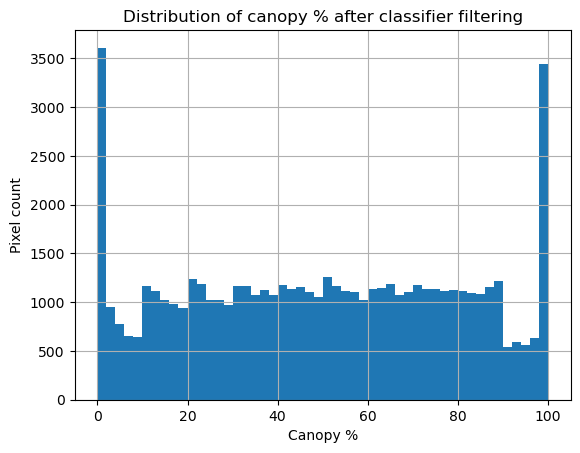

In [22]:
y_train.hist(bins=50)
plt.xlabel("Canopy %")
plt.ylabel("Pixel count")
plt.title("Distribution of canopy % after classifier filtering")
plt.savefig("y_train_dist.png")

print(y_train.describe())
print(f"% pixels below 10% canopy: {100*(y_train < 10).mean():.1f}%")

In [23]:
##### classifier false positives ###### zero canopy pixels that look like tc to the model
print(f"True zero canopy pixels passed by classifier: {(y_train == 0).sum():,}")
print(f"As % of training set: {100*(y_train == 0).mean():.1f}%")

# also check what proba the classifier assigned these pixels
zero_mask = train_filtered['canopy_pct'] == 0
train_feats = train_filtered.iloc[:,clf_feat_idx]

zero_probas = clf.predict_proba(
    train_feats[zero_mask]
)[:, 1]
print(f"Mean classifier proba for zero-canopy pixels: {zero_probas.mean():.3f}")
print(f"Proba distribution:\n{pd.Series(zero_probas).describe()}")


True zero canopy pixels passed by classifier: 1,964
As % of training set: 3.4%
Mean classifier proba for zero-canopy pixels: 0.544
Proba distribution:
count    1964.000000
mean        0.543508
std         0.165468
min         0.316422
25%         0.405427
50%         0.512992
75%         0.650848
max         0.994493
dtype: float64


In [ ]:
#### classifier false negatives #### canopy pixels that are left out of regressor training
# could be reduced by lowering classifier decision threshold (less strict classification)
all_true_canopy = test_df[test_df['canopy_pct'] > 0]
all_true = all_true_canopy.iloc[:,clf_feat_idx]
clf_proba = clf.predict_proba(all_true)[:, 1]
missed = clf_proba < threshold

print(f"True canopy pixels missed by classifier: {missed.sum():,} "
      f"({100*missed.mean():.1f}%)")
print(f"Mean canopy % of missed pixels: "
      f"{all_true_canopy['canopy_pct'][missed].mean():.1f}%")
print(f"\nCanopy % distribution of missed pixels:")
print(all_true_canopy['canopy_pct'][missed].describe())

## most are below 10% canopy - shouldn't affect final rmse too much



True canopy pixels missed by classifier: 939 (7.3%)
Mean canopy % of missed pixels: 8.1%

Canopy % distribution of missed pixels:
count    939.000000
mean       8.108415
std       11.270360
min        0.000811
25%        1.192146
50%        4.018819
75%       10.796776
max      100.000000
Name: canopy_pct, dtype: float64


### Feature selection for regression

In [21]:
import joblib
import os
from sklearn.metrics import mean_squared_error, r2_score

siteyear= 'nyc18'

train_df = pd.read_parquet(root / 'data' / siteyear / 'train_df_rgr_nonstratified.parquet')
test_df = pd.read_parquet(root / 'data' / siteyear / 'test_df_rgr_nonstratified.parquet')

feature_cols = [c for c in train_df.columns if c.startswith('band')]

X_train = train_df.loc[:,feature_cols]
y_train = train_df['canopy_pct']

X_test = test_df.loc[:,feature_cols]
y_test = test_df['canopy_pct']

rgr = RandomForestRegressor( n_estimators=100,
    min_samples_leaf=5,
    max_depth=20,
    n_jobs=-1,
    random_state=42)

rgr.fit(X_train,y_train)

## baseline scores
y_pred = rgr.predict(X_test)
print("Train predictions range:", y_pred.min(), y_pred.max())
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Test R²:", r2_score(y_test, y_pred))

out_path = root / 'models' / siteyear
os.makedirs(out_path,exist_ok=True)

joblib.dump({"rgr_model":rgr}, out_path / f'{siteyear}_baseline_rgr.joblib')

Train predictions range: 0.02670945182364313 99.77187071802955
Test RMSE: 15.510950032414907
Test R²: 0.7806861318403254


['c:\\Users\\roseh\\Documents\\utc_paper\\models\\nyc18\\nyc18_baseline_rgr.joblib']

In [59]:
print("Base values:", shap_values.base_values[:5])
print("SHAP sum range:", shap_values.values.sum(axis=1).min(), 
                         shap_values.values.sum(axis=1).max())

Base values: [24.19999227 24.19999227 24.19999227 24.19999227 24.19999227]
SHAP sum range: -71835.58179099378 19093.577453102444


In [22]:
rgr_bundle = joblib.load(root / 'models' / siteyear / f'{siteyear}_baseline_rgr.joblib')
rgr = rgr_bundle["rgr_model"]

In [ ]:
### try out shap on small sample and manually check additivity 
# check_additivity set to False to avoid errors

X_small = X_test.sample(50, random_state=50)

explainer = shap.TreeExplainer(rgr)

shap_values = explainer(X_small, check_additivity=False)

pred = rgr.predict(X_small)

# shap value and base value should sum to model prediction
shap_sum = shap_values.values.sum(axis=1) + shap_values.base_values

diff = pred - shap_sum

rel_error = np.abs(diff) / (np.abs(pred)+1e-16)
print("mean rel error:", np.nanmean(rel_error))
print("max rel error:", np.nanmax(rel_error))

## 2021. turns out the model with default parameters was likely overfit. This also likely suppressed r2/rmse on the num_features plot.
## mean error of 1.5% is acceptable. Max error of 39% an outlier. 
# mean rel error: 0.015870673626769825
# max rel error: 0.39349819887829957

### 2017 -- very tiny error
# mean rel error: 8.17984036889111e-14
# max rel error: 1.2174611792133382e-12

## 2018
# mean rel error: 3.3008957217484087e-13
# max rel error: 1.0722403581750513e-11

In [24]:
columns = X_small.columns
vals = np.abs(shap_values.values).mean(axis=0)
ranking2 = pd.Series(vals, index=columns).sort_values(ascending=False)


In [25]:

### get absolute shap values and make dataframe
vals = shap_values.values
mean_abs_shap = np.abs(vals).mean(axis=0)

shap_df = pd.DataFrame({
    'feature': X_small.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)



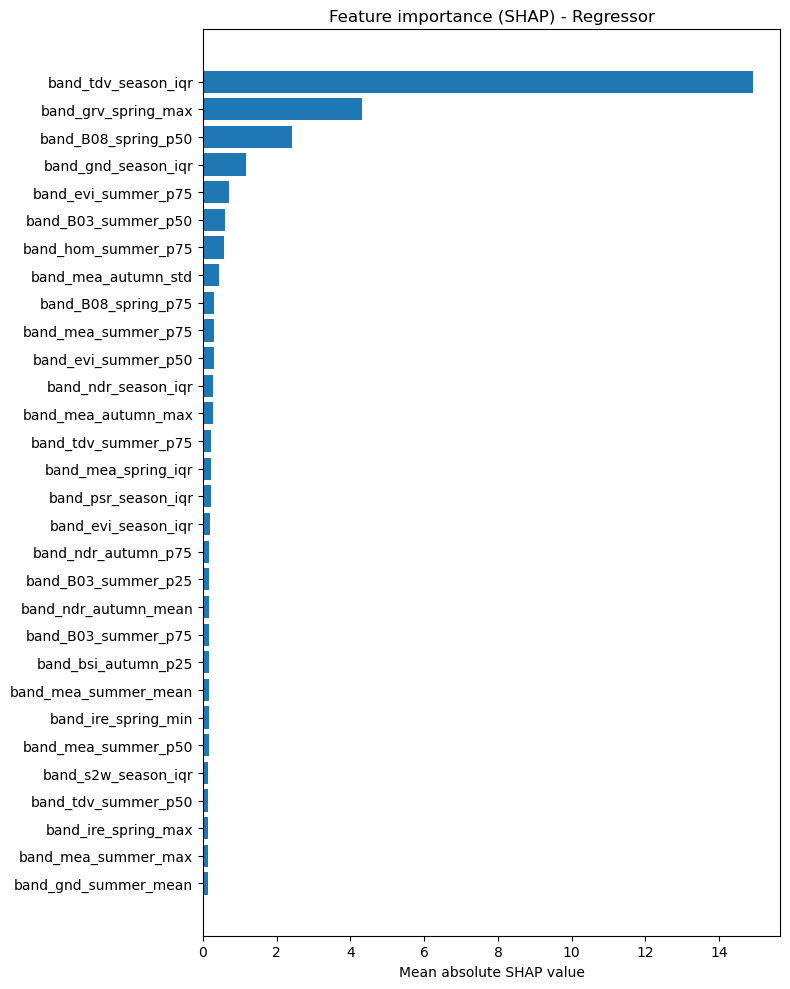

In [26]:
# Plot top 30
top30 = shap_df.head(30)
plt.figure(figsize=(8, 10))
plt.barh(top30['feature'][::-1], top30['mean_abs_shap'][::-1])
plt.xlabel('Mean absolute SHAP value')
plt.title('Feature importance (SHAP) - Regressor')
plt.tight_layout()
plt.show()

In [27]:
## cluster correlated variables
# reduce correlated groups down to a single 'representative' variable
t = 0.15
corr = pd.DataFrame(X_small).corr().abs()
distance = 1 - corr
linkage = hierarchy.ward(squareform(distance))
labels = hierarchy.fcluster(linkage, t=t, criterion='distance')

# for each cluster, keep the one variable with highest shap value
selected = []
for cluster_id in np.unique(labels):
    members = X_train.columns[labels == cluster_id]
    # Pick member with highest mean absolute SHAP
    best = shap_df[shap_df['feature'].isin(members)].iloc[0]['feature']
    selected.append(best)

len(selected)   ## number of clusters = 410

322

In [28]:
#### plot baseline scores with increasing number of features
def test_features_rgr(features,X_train,X_test,y_train,y_test):
    rmse_scores = []
    r2_scores = []
    num_features = []

     # Step through feature counts rather than every single one
    steps = list(range(1, 20)) + list(range(20, 100, 5)) + list(range(100, len(features)+1, 20))
    steps = [s for s in steps if s <= len(features)]

    for i in steps:
        feature_set = features[0:i+1]
        X_train_reduced = X_train[feature_set]
        X_test_reduced = X_test[feature_set]
        
        # fit model for permutation imp
        rf = RandomForestRegressor(
                min_samples_leaf=5,
                max_depth=20,
                max_features='sqrt',
                n_jobs=-1,
                random_state=42,
        )
        rf.fit(X_train_reduced, y_train)

        y_pred = rf.predict(X_test_reduced)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred=y_pred))
        r2 = r2_score(y_test,y_pred=y_pred)
        rmse_scores.append(rmse)
        num_features.append(X_train_reduced.shape[1])
        r2_scores.append(r2)

    out_df = pd.DataFrame({'num_features':num_features,'rmse':rmse_scores,'r2':r2_scores})

    return out_df




In [29]:
# add features in order of shap value
features_ordered = shap_df[shap_df['feature'].isin(selected)]['feature'].tolist()
scores_df = test_features_rgr(features=features_ordered,X_train=X_train,y_train=y_train,X_test=X_test,y_test=y_test)

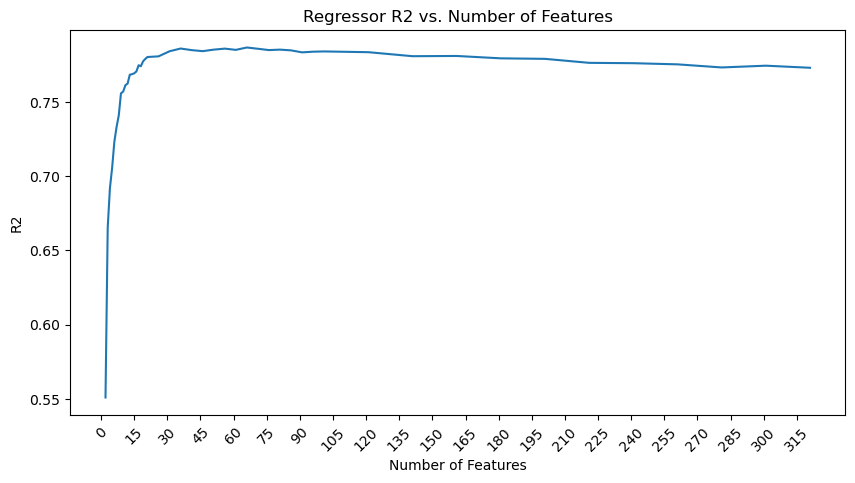

In [30]:
fig,ax = plt.subplots(figsize=(10,5))
scores_df.plot(x='num_features',y='r2',ax=ax,legend=False)
ax.set_xticks(np.arange(0,len(features_ordered),15))
ax.set_xticklabels(labels=ax.get_xticks(),rotation=45)
ax.set_ylabel('R2')
ax.set_xlabel('Number of Features')
ax.set_title('Regressor R2 vs. Number of Features')

plt.show()

In [31]:
scores_df.loc[scores_df['rmse']==np.min(scores_df['rmse'])]

,num_features,rmse,r2
28,66,15.288077,0.786943


In [32]:
scores_df.loc[(scores_df['num_features']>=30)&(scores_df['num_features']<=70)]

,num_features,rmse,r2
21,31,15.378865,0.784405
22,36,15.312894,0.786251
23,41,15.351538,0.785171
24,46,15.376208,0.784480
25,51,15.339977,0.785494
26,56,15.315370,0.786182
27,61,15.345342,0.785344
28,66,15.288077,0.786943


In [33]:
# keep top 40 and write to file
keep_features = features_ordered[:51]

fp = root / 'data' / siteyear / 'rgr_features.json'

with open(fp,'w') as f:
    json.dump(keep_features,f)

### Tune regressor using top features only

In [34]:
train_df = pd.read_parquet(root / 'data' / siteyear / 'train_df_rgr_nonstratified.parquet')
test_df = pd.read_parquet(root / 'data' / siteyear / 'test_df_rgr_nonstratified.parquet')

fp = root / 'data' / siteyear / 'rgr_features.json'
with open(fp,'r') as f:
    rgr_feature_cols = json.load(f)


X_train_tf = train_df.loc[:,rgr_feature_cols]
y_train = train_df['canopy_pct']

X_test_tf = test_df.loc[:,rgr_feature_cols]
y_test = test_df['canopy_pct']

## groups to make sure train/test pixels are sampled from different blocks
block_ids_tr = (train_df["block_row"].astype(str) + "_"
                + train_df["block_col"].astype(str))
group_encoder = {g: i for i, g in enumerate(block_ids_tr.unique())}
groups_tr = block_ids_tr.map(group_encoder).values

n_cv_folds = min(5, len(np.unique(groups_tr)))
cv_spatial = GroupKFold(n_splits=n_cv_folds)

In [35]:
def objective(trial):

    params= {
        "min_samples_leaf" : trial.suggest_int("min_samples_leaf", 2, 10),
        "max_samples"      : trial.suggest_float("max_samples", 0.6, 1.0),
        "max_depth" : trial.suggest_int("max_depth",25,40),
        "max_features": trial.suggest_float("max_features",0.3,0.8)}
    
    rgr = RandomForestRegressor(**params,n_estimators=100,n_jobs=1,random_state=42)

    scores = cross_val_score(rgr,X_train_tf,y_train,cv=cv_spatial,groups=groups_tr,scoring='neg_root_mean_squared_error',n_jobs=-1)

    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective,n_trials=10,show_progress_bar=True)

[I 2026-05-07 19:19:53,419] A new study created in memory with name: no-name-abee0f95-3058-42c3-b368-7dc626bcaae8


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-05-07 19:22:52,674] Trial 0 finished with value: -15.132182442489661 and parameters: {'min_samples_leaf': 6, 'max_samples': 0.9183343472862586, 'max_depth': 25, 'max_features': 0.7414605043913443}. Best is trial 0 with value: -15.132182442489661.
[I 2026-05-07 19:24:40,358] Trial 1 finished with value: -15.202854120022675 and parameters: {'min_samples_leaf': 9, 'max_samples': 0.7250423291919806, 'max_depth': 25, 'max_features': 0.5325977763445927}. Best is trial 0 with value: -15.132182442489661.
[I 2026-05-07 19:26:01,721] Trial 2 finished with value: -15.194537850682774 and parameters: {'min_samples_leaf': 9, 'max_samples': 0.895406411850949, 'max_depth': 35, 'max_features': 0.3267913736179393}. Best is trial 0 with value: -15.132182442489661.
[I 2026-05-07 19:28:18,277] Trial 3 finished with value: -15.1145352744153 and parameters: {'min_samples_leaf': 5, 'max_samples': 0.7873524484563447, 'max_depth': 38, 'max_features': 0.5932908125948464}. Best is trial 3 with value: -15.

In [36]:
study.best_params

# {'min_samples_leaf': 5,
#  'max_samples': 0.9932171045913557,
#  'max_depth': 30,
#  'max_features': 0.4899561716985441}

{'min_samples_leaf': 5,
 'max_samples': 0.7978292758238771,
 'max_depth': 32,
 'max_features': 0.500085854257251}

In [ ]:


best_rgr = RandomForestRegressor(
    **study.best_params, n_estimators=100,n_jobs=1,random_state=42
)
best_rgr.fit(X_train_tf, y_train) ## fit on all training data

y_pred  = best_rgr.predict(X_test_tf)

rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

print(f'rmse: {rmse}, r2: {r2}')

# 2021 dsen2
#rmse: 15.686999880893467, r2: 0.7827594502456455

# 2021 bilinear resampling
# rmse: 15.664901236935487, r2: 0.7833437322175888

# 2021 season only
# rmse: 17.958655636016672, r2: 0.7152860463300356

## 2017 resampled  ### could worse performance be due to less spring data?
#rmse: 17.102737236436365, r2: 0.7411122119720446

## 2018
#rmse: 15.228454860259868, r2: 0.788601949519962

rmse: 15.228454860259868, r2: 0.7886019495199623


In [38]:
#save best_estimator and features

out_path = root / 'models' / siteyear
os.makedirs(out_path,exist_ok=True)

joblib.dump({"rgr_model":best_rgr,
         "features":rgr_feature_cols,
         "params": study.best_params}, out_path / f'{siteyear}_rgr.joblib')

['c:\\Users\\roseh\\Documents\\utc_paper\\models\\nyc18\\nyc18_rgr.joblib']

In [ ]:
resids = y_pred - y_test
abs_resids = np.abs(resids)

print(f"Mean bias: {resids.mean():.2f}  # positive = overpredicting")
print(f"Median bias: {np.median(resids):.2f}")

# Mean bias: 0.29  # positive = overpredicting
# Median bias: 1.31

# season only
# Mean bias: 0.35 
# Median bias: 1.42

# 2017 resampled 
# Mean bias: 0.11  
# Median bias: 1.54

# 2018
# Mean bias: -0.00 
# Median bias: 1.22

Mean bias: -0.00  # positive = overpredicting
Median bias: 1.22


In [41]:
def residuals_scatterplot(y_pred,y_test,resids):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Residuals vs predicted
    axes[0].scatter(y_pred, resids, alpha=0.2, s=5)
    axes[0].axhline(0, color='red', linewidth=1)
    axes[0].set_xlabel('Predicted canopy %')
    axes[0].set_ylabel('Residual (pred - actual)')
    axes[0].set_title('Residuals vs Predicted')

    # Predicted vs actual
    axes[1].scatter(y_test, y_pred, alpha=0.2, s=5)
    axes[1].plot([0, 100], [0, 100], 'r--', linewidth=1)
    axes[1].set_xlabel('Actual canopy %')
    axes[1].set_ylabel('Predicted canopy %')
    axes[1].set_title('Predicted vs Actual')
    plt.tight_layout()

## shape results because residual cannot be larger than actual canopy value

## known regression to the mean property of random forest models

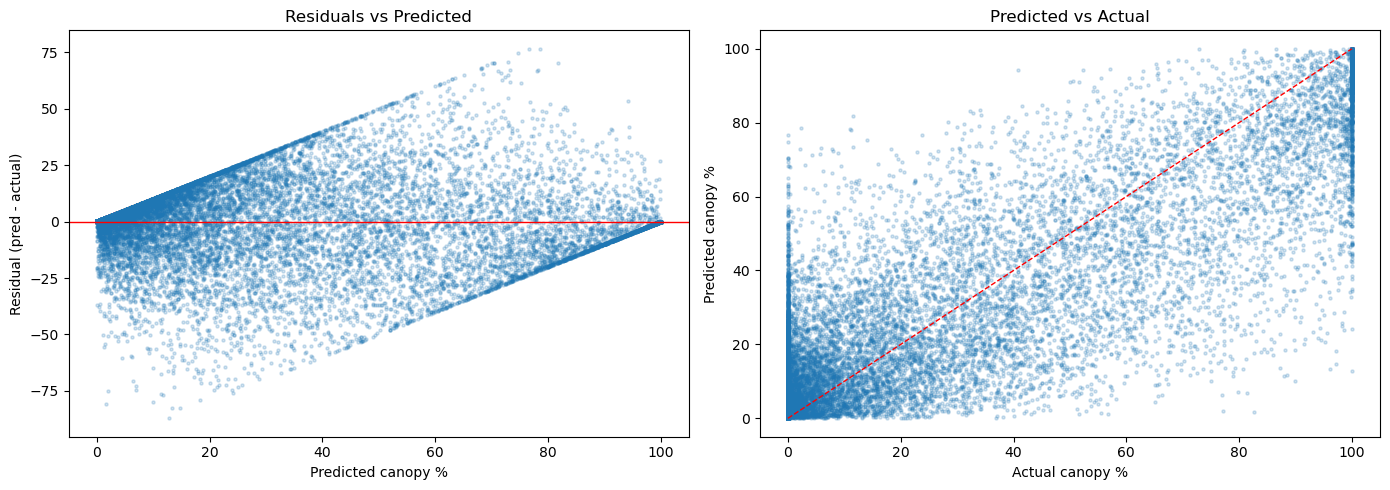

In [110]:
residuals_scatterplot(y_pred=y_pred,y_test=y_test,resids=resids)

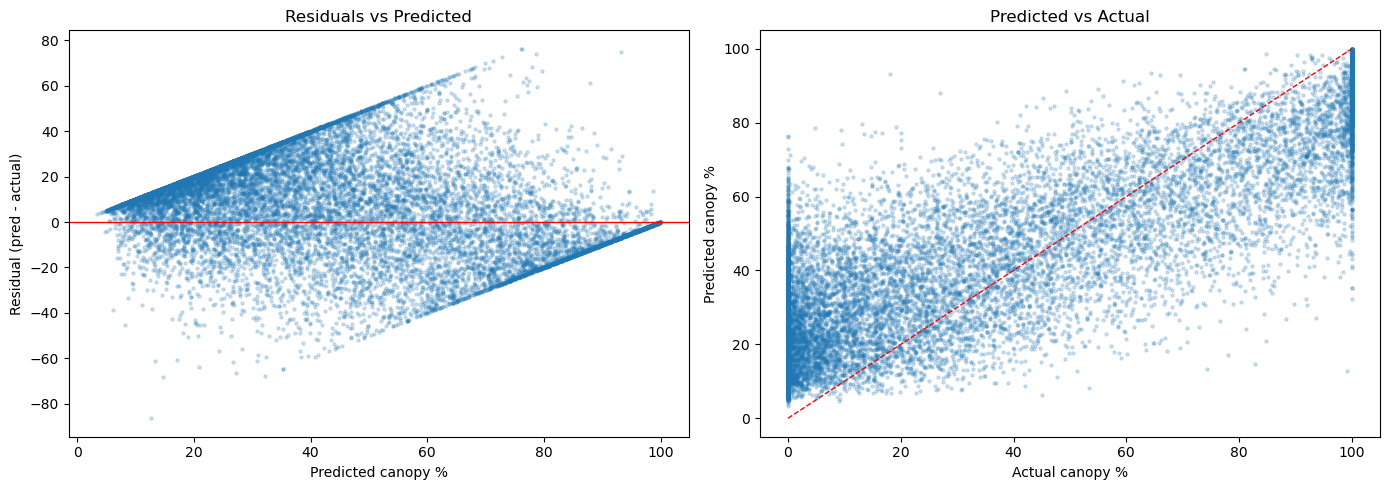

In [44]:
residuals_scatterplot(y_pred=y_pred,y_test=y_test,resids=resids)

      bin  mean_bias       rmse  count
0    0-10   8.588115  14.502884   3410
1   10-20   4.004280  15.023145   1560
2   20-30   0.080022  16.455242   1147
3   30-40  -3.804531  18.851297   1018
4   40-50  -7.274095  20.623813    818
5   50-60 -10.278134  22.373436    742
6   60-70 -13.133192  23.856952    682
7   70-80 -17.477399  27.470244    626
8   80-90 -18.297733  26.807913    679
9  90-100 -14.121838  20.921001   2173


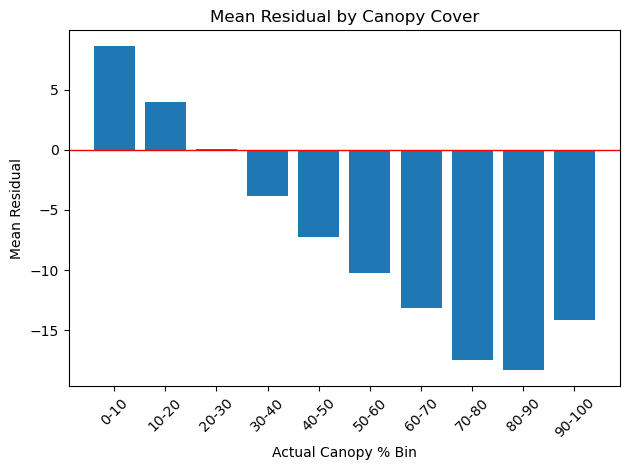

In [ ]:
bias_barplot(y_test=y_test,resids=resids)

# before
#    bin  mean_bias       rmse  count
# 0    0-10  21.414970  24.747358   2715
# 1   10-20  16.531270  21.428014   1429
# 2   20-30  10.333018  17.662333   1143
# 3   30-40   5.517177  15.221579    982
# 4   40-50   1.755632  14.771298    878
# 5   50-60  -2.088632  15.026035    749
# 6   60-70  -7.499172  16.484028    686
# 7   70-80 -12.386231  18.447879    634
# 8   80-90 -16.909854  21.850429    664
# 9  90-100 -16.333265  20.396845   2114

# after - uncorrected
#       bin  mean_bias       rmse  count
# 0    0-10  17.456967  21.871916   3400
# 1   10-20  14.074580  20.367938   1589
# 2   20-30   9.199020  17.534057   1190
# 3   30-40   4.622500  15.402951   1005
# 4   40-50   1.136421  14.989127    888
# 5   50-60  -2.455286  15.588775    755
# 6   60-70  -7.780027  17.007096    691
# 7   70-80 -12.337812  18.579560    635
# 8   80-90 -17.023474  22.066777    664
# 9  90-100 -16.243863  20.417239   2116

# corrected
#  bin  mean_bias       rmse  count
# 0    0-10  15.941366  21.138881   3400
# 1   10-20  12.969502  20.236725   1589
# 2   20-30   8.389662  17.844651   1190
# 3   30-40   4.119651  16.043366   1005
# 4   40-50   0.992375  15.801887    888
# 5   50-60  -2.240384  16.382140    755
# 6   60-70  -7.302814  17.545636    691
# 7   70-80 -11.552265  18.661492    635
# 8   80-90 -15.933707  21.754816    664
# 9  90-100 -14.517255  19.435856   2116

## nonstratified sample
#       bin  mean_bias       rmse  count
# 0    0-10   8.588115  14.502884   3410
# 1   10-20   4.004280  15.023145   1560
# 2   20-30   0.080022  16.455242   1147
# 3   30-40  -3.804531  18.851297   1018
# 4   40-50  -7.274095  20.623813    818
# 5   50-60 -10.278134  22.373436    742
# 6   60-70 -13.133192  23.856952    682
# 7   70-80 -17.477399  27.470244    626
# 8   80-90 -18.297733  26.807913    679
# 9  90-100 -14.121838  20.921001   2173


## 2017 resampled 
#       bin  mean_bias       rmse  count
# 0    0-10   9.762221  15.869360   3085
# 1   10-20   4.840467  15.666396   1406
# 2   20-30   0.206197  17.032274   1067
# 3   30-40  -3.432659  19.252220    866
# 4   40-50  -9.542589  21.899648    752
# 5   50-60 -12.817776  24.091594    670
# 6   60-70 -15.180207  25.520510    579
# 7   70-80 -19.820744  28.470249    547
# 8   80-90 -24.420064  31.424935    609
# 9  90-100 -17.830523  24.790074   1962

### same residual patterns in both years suggests models are learning same fundamental patterns. 2017 input data could be noisier due to fewer data aquisitions; Sentinel-2 2B was not fully operational until late 2017. fewer acquisitions in spring especially impactful.


In [ ]:
# Compare feature distributions between years
for col in X_train_2017.columns[:10]:
    print(f"{col}:")
    print(f"  2017: mean={X_train_2017[col].mean():.3f}, std={X_train_2017[col].std():.3f}")
    print(f"  2021: mean={X_train_2021[col].mean():.3f}, std={X_train_2021[col].std():.3f}")

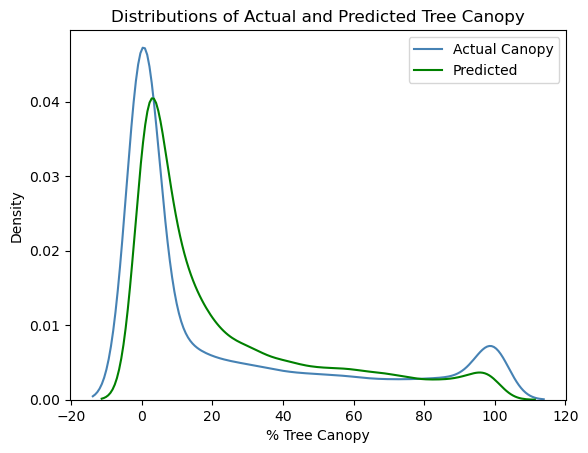

In [93]:
fig, ax = plt.subplots()
sns.kdeplot(y_test,ax=ax,color='steelblue',label='Actual Canopy')
#sns.kdeplot(y_pred_iso,ax=ax,color='orange',label='Predicted - iso')
sns.kdeplot(y_pred,ax=ax,color='green',label='Predicted')
#ax.axvline(0,linestyle='--',color='gray',alpha=0.4)
ax.set_xlabel('% Tree Canopy')
plt.legend()
plt.title('Distributions of Actual and Predicted Tree Canopy')
plt.show()

In [112]:
# Check what the citywide pixel distribution looks like
print(pd.Series(y_train).describe())
print(f"% pixels below 10%: {(y_train < 10).mean():.1%}")
print(f"% pixels 10-90%: {((y_train >= 10) & (y_train <= 90)).mean():.1%}")
print(f"% pixels above 90%: {(y_train > 90).mean():.1%}")

count    53459.000000
mean        24.638281
std         34.348801
min          0.000000
25%          0.000000
50%          3.070950
75%         42.938211
max        100.000000
Name: canopy_pct, dtype: float64
% pixels below 10%: 57.4%
% pixels 10-90%: 32.1%
% pixels above 90%: 10.5%


      bin  mean_bias       rmse  count
0    0-10   9.762221  15.869360   3085
1   10-20   4.840467  15.666396   1406
2   20-30   0.206197  17.032274   1067
3   30-40  -3.432659  19.252220    866
4   40-50  -9.542589  21.899648    752
5   50-60 -12.817776  24.091594    670
6   60-70 -15.180207  25.520510    579
7   70-80 -19.820744  28.470249    547
8   80-90 -24.420064  31.424935    609
9  90-100 -17.830523  24.790074   1962


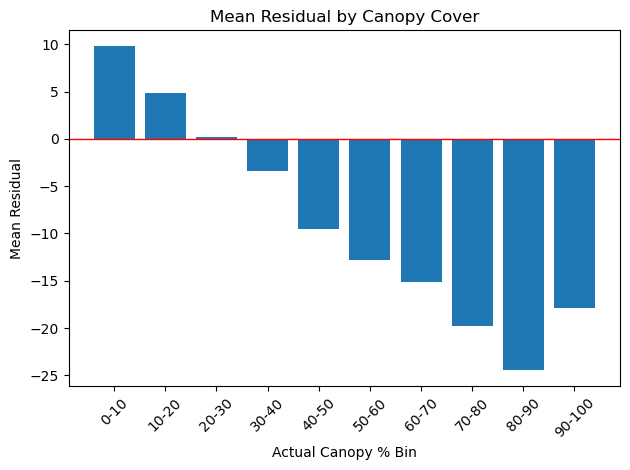

In [95]:
bias_barplot(y_test=y_test,resids=resids)

In [94]:
def bias_barplot(y_test,resids):

    abs_resids = np.abs(resids)
    bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
    bin_labels = [f'{b}-{bins[i+1]}' for i, b in enumerate(bins[:-1])]
    bin_ids = pd.cut(y_test, bins=bins, labels=bin_labels)

    bin_stats = pd.DataFrame({
        'residual': resids,
        'abs_residual': abs_resids,
        'bin': bin_ids
    }).groupby('bin').agg(
        mean_bias=('residual', 'mean'),
        rmse=('residual', lambda x: np.sqrt(np.mean(x**2))),
        count=('residual', 'count')
    ).reset_index()

    print(bin_stats)

    # # Plot bias by bin
    fig, ax = plt.subplots()

    ax.bar(bin_stats['bin'], bin_stats['mean_bias'])
    ax.axhline(0, color='red', linewidth=1)
    ax.set_xlabel('Actual Canopy % Bin')
    ax.set_ylabel('Mean Residual')
    ax.set_title('Mean Residual by Canopy Cover')
    ax.tick_params(axis='x', rotation=45)

    # axes[1].bar(bin_stats['bin'], bin_stats['rmse'])
    # axes[1].set_xlabel('Actual Canopy % Bin')
    # axes[1].set_ylabel('RMSE')
    # axes[1].set_title('RMSE by Canopy Cover')
    # axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()

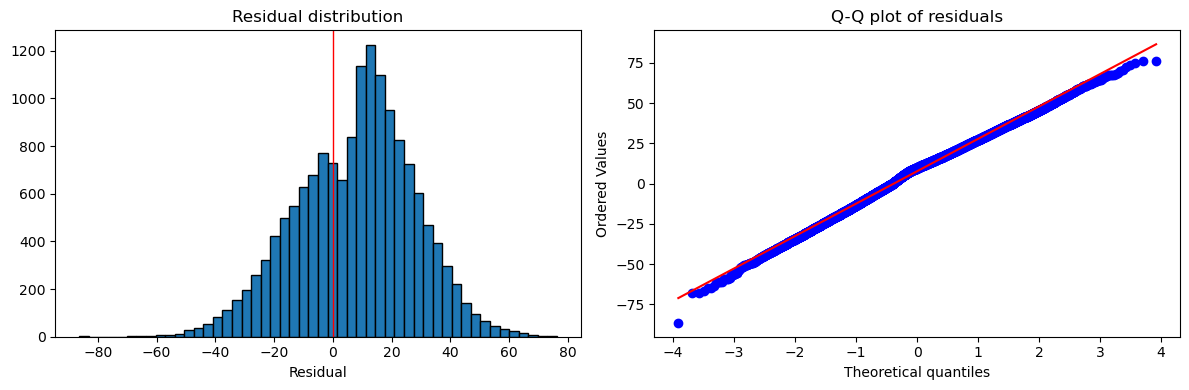

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(resids, bins=50, edgecolor='black')
axes[0].axvline(0, color='red', linewidth=1)
axes[0].set_xlabel('Residual')
axes[0].set_title('Residual distribution')

# Q-Q plot to check normality
from scipy import stats
stats.probplot(resids, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q plot of residuals')
plt.tight_layout()